In [2]:
import datetime
import math
import warnings
from itertools import cycle
import numpy as np
import pandas as pd


import lightgbm as lgb
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    explained_variance_score,
    mean_absolute_error,
    mean_gamma_deviance,
    mean_poisson_deviance,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    TimeSeriesSplit,
    train_test_split
)
from sklearn.preprocessing import RobustScaler, StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    BatchNormalization,
    Bidirectional,
    Dense,
    Dropout,
    LSTM
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import mplfinance as mpf
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import joblib
from pytz import timezone
from tqdm import tqdm

ModuleNotFoundError: No module named 'numpy'

In [6]:
def analyze_btc_data(df):
    tz = timezone('Europe/Moscow')
    df['datetime'] = (pd.to_datetime(df['timestamp'], unit='ms')
                      .dt.tz_localize('UTC')
                      .dt.tz_convert(tz))
    
    metadata = {
        'start_date': df['datetime'].min().strftime('%Y-%m-%d %H:%M:%S %Z%z'),
        'end_date': df['datetime'].max().strftime('%Y-%m-%d %H:%M:%S %Z%z'),
        'total_records': len(df)
    }

    columns_report = {}
    for column in df.columns:
        report = {
            'nulls': df[column].isnull().sum(),
            'zeros': (df[column] == 0).sum() if df[column].dtype in ['int64', 'float64'] else 'N/A'
        }
        columns_report[column] = report

    flags = {
        'has_duplicates': df.duplicated().sum() > 0,
        'has_nulls': any(report['nulls'] > 0 for report in columns_report.values()),
        'has_zeros': any(isinstance(report['zeros'], int) and report['zeros'] > 0 
                       for report in columns_report.values())
    }

    return {
        'metadata': metadata,
        'columns_report': columns_report,
        'flags': flags
    }

df = pd.read_csv('bybit_daily.csv')
result = analyze_btc_data(df)

print("=== Метаданные ===")
print(f"Период: {result['metadata']['start_date']} - {result['metadata']['end_date']}")
print(f"Всего записей: {result['metadata']['total_records']}\n")

print("=== Общие проблемы ===")
print(f"Дубликаты: {'⚠️ Есть' if result['flags']['has_duplicates'] else '✅ Нет'}")
print(f"Пропуски: {'⚠️ Есть' if result['flags']['has_nulls'] else '✅ Нет'}")
print(f"Нулевые значения: {'⚠️ Есть' if result['flags']['has_zeros'] else '✅ Нет'}\n")

=== Метаданные ===
Период: 2021-01-01 03:00:00 MSK+0300 - 2025-05-30 03:00:00 MSK+0300
Всего записей: 1610

=== Общие проблемы ===
Дубликаты: ✅ Нет
Пропуски: ✅ Нет
Нулевые значения: ✅ Нет



Пропусков и нулевых значений нету, следовательно данные мне подходят и очистки не требуют

Loading data: 1chunk [00:00, 10.55chunk/s]


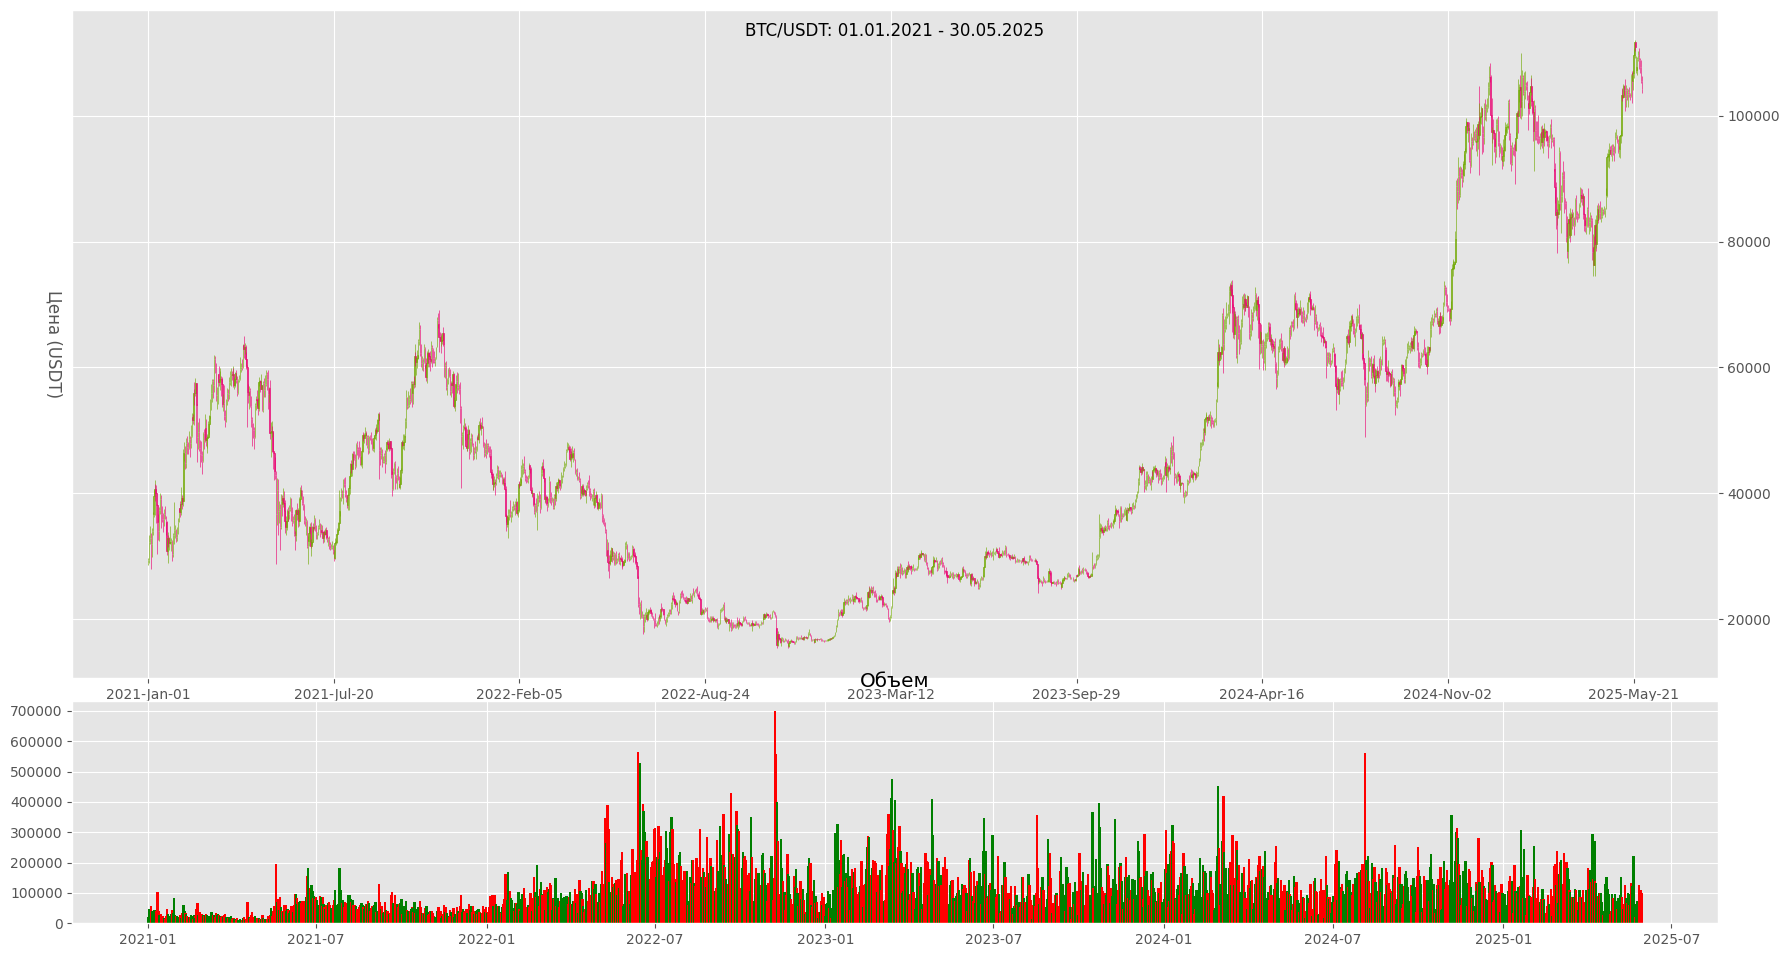

In [7]:
INPUT_FILE = 'bybit_daily.csv'
TIMEZONE = timezone('Europe/Moscow')
MAX_DISPLAY_POINTS = 5000

def load_data(file_path: str) -> pd.DataFrame:
    dtypes = {
        'open': 'float32',
        'high': 'float32',
        'low': 'float32',
        'close': 'float32',
        'volume': 'float32'
    }
    chunks = []
    with tqdm(desc="Loading data", unit="chunk") as pbar:
        for chunk in pd.read_csv(
            file_path,
            usecols=['timestamp', 'open', 'high', 'low', 'close', 'volume'],
            dtype=dtypes,
            parse_dates=['timestamp'],
            date_parser=lambda x: pd.to_datetime(x, unit='ms', utc=True),
            chunksize=500000
        ):
            chunk['timestamp'] = chunk['timestamp'].dt.tz_convert(TIMEZONE)
            chunks.append(chunk)
            pbar.update(1)
    
    df = pd.concat(chunks)
    return df.set_index('timestamp').sort_index()

def dynamic_resample(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) > MAX_DISPLAY_POINTS:
        ratio = len(df) // MAX_DISPLAY_POINTS
        return df.resample(f'{ratio}T').agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    return df

df = load_data(INPUT_FILE)
plot_df = dynamic_resample(df)

plt.style.use('ggplot')
plt.rcParams.update({
    'figure.figsize': (18, 10),
    'lines.linewidth': 0.5,
    'font.size': 10
})

fig, axes = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]})

mpf.plot(
    plot_df,
    type='candle',
    ax=axes[0],
    style='binance',
    show_nontrading=False,
    xrotation=0,
    warn_too_much_data=len(plot_df)+1
)

axes[0].yaxis.tick_right()
axes[0].set_ylabel('Цена (USDT)', rotation=-90, labelpad=20, va='bottom')

axes[1].bar(
    plot_df.index,
    plot_df['volume'],
    color=np.where(plot_df['close'] >= plot_df['open'], 'g', 'r'),
    width=0.8/(len(plot_df)/MAX_DISPLAY_POINTS)
)
axes[1].set_title('Объем', pad=10)

plt.suptitle(
    f"BTC/USDT: {plot_df.index[0]:%d.%m.%Y} - {plot_df.index[-1]:%d.%m.%Y}",
    y=0.94
)
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()

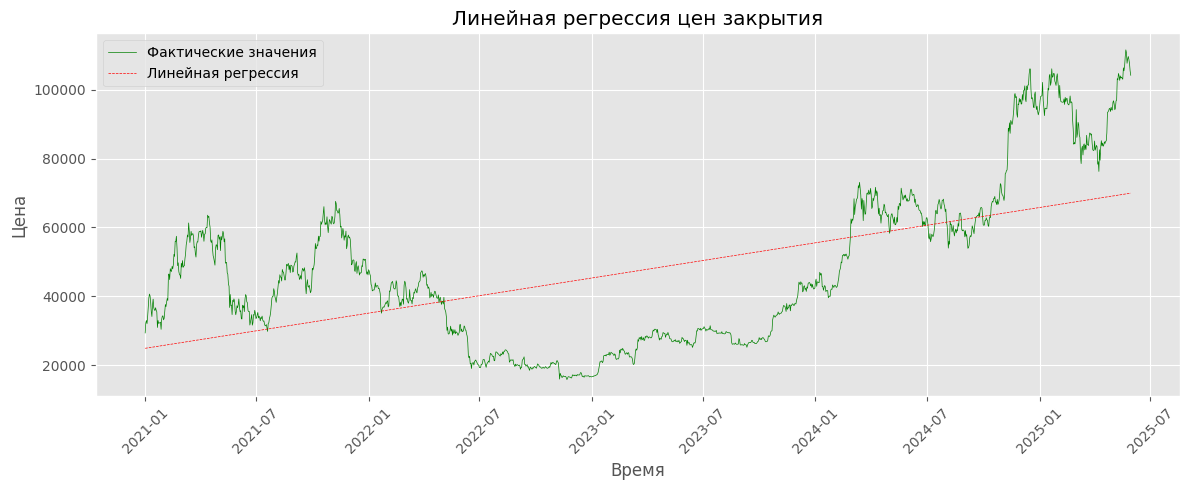

MSE: 381704291.55


In [8]:
df = pd.read_csv('bybit_daily.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

X = np.arange(len(df)).reshape(-1, 1) 
y = df['close'].values


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
future_steps = 5
X_future = np.arange(len(df), len(df) + future_steps).reshape(-1, 1)
future_pred = model.predict(X_future)

plt.figure(figsize=(12, 5))
plt.plot(df.index, y, 'g-', label='Фактические значения')
plt.plot(df.index, y_pred, 'r--', label='Линейная регрессия')
plt.title('Линейная регрессия цен закрытия')
plt.xlabel('Время')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"MSE: {mean_squared_error(y, y_pred):.2f}")

Даже линейная регрессия показывает общую тенденцию рынка биткоина

In [9]:
df1 = pd.read_csv('bybit_daily.csv')
df1.timestamp = pd.to_datetime(df1.timestamp, unit='ms')
df1.index = df1.timestamp
df1 = df1.resample('D').mean()
df1.head()

,timestamp,open,high,low,close,volume,turnover
timestamp,,,,,,,
2021-01-01,2021-01-01,28921.5,29673.5,28654.0,29325.0,19234.412,5.640491e+08
2021-01-02,2021-01-02,29325.0,33450.0,28967.5,32230.0,47478.703,1.530239e+09
2021-01-03,2021-01-03,32230.0,34820.0,32016.5,32963.0,46033.177,1.517392e+09
2021-01-04,2021-01-04,32963.0,33616.5,27923.0,32024.0,55935.783,1.791288e+09
2021-01-05,2021-01-05,32024.0,34496.5,29905.5,34019.5,39382.593,1.339776e+09


In [10]:
df1.timestamp = pd.to_datetime(df1.timestamp, unit='ms')
df1.index = df1.timestamp
df1 = df1.resample('D').mean()
df1.head()

,timestamp,open,high,low,close,volume,turnover
timestamp,,,,,,,
2021-01-01,2021-01-01,28921.5,29673.5,28654.0,29325.0,19234.412,5.640491e+08
2021-01-02,2021-01-02,29325.0,33450.0,28967.5,32230.0,47478.703,1.530239e+09
2021-01-03,2021-01-03,32230.0,34820.0,32016.5,32963.0,46033.177,1.517392e+09
2021-01-04,2021-01-04,32963.0,33616.5,27923.0,32024.0,55935.783,1.791288e+09
2021-01-05,2021-01-05,32024.0,34496.5,29905.5,34019.5,39382.593,1.339776e+09


In [11]:
price = df1.close
X = price.values
size = int(len(X) * 0.7)
train, test = X[0:size], X[size:len(X)]

history = [x for x in train]
predictions = list()

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)
    print(f'Предсказание: {yhat:.2f}, Фактическое: {obs:.2f}')

rmse = np.sqrt(mean_squared_error(test, predictions))
r2 = r2_score(test, predictions)
mape = np.mean(np.abs((test - predictions) / test)) * 100 
print(f'\nRMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

Предсказание: 43099.11, Фактическое: 43178.10
Предсказание: 43198.09, Фактическое: 42991.80
Предсказание: 42976.66, Фактическое: 42559.60
Предсказание: 42576.95, Фактическое: 42692.60
Предсказание: 42703.85, Фактическое: 43083.90
Предсказание: 43068.53, Фактическое: 44318.00
Предсказание: 44280.72, Фактическое: 45260.50
Предсказание: 45256.25, Фактическое: 47122.40
Предсказание: 47143.66, Фактическое: 47728.10
Предсказание: 47816.56, Фактическое: 48328.50
Предсказание: 48430.14, Фактическое: 49960.90
Предсказание: 50064.44, Фактическое: 49710.40
Предсказание: 49823.36, Фактическое: 51821.80
Предсказание: 51861.58, Фактическое: 51904.20
Предсказание: 52015.75, Фактическое: 52151.80
Предсказание: 52224.54, Фактическое: 51693.10
Предсказание: 51787.81, Фактическое: 52174.90
Предсказание: 52235.66, Фактическое: 51814.90
Предсказание: 51832.26, Фактическое: 52287.10
Предсказание: 52270.93, Фактическое: 51875.20
Предсказание: 51888.59, Фактическое: 51304.70
Предсказание: 51313.74, Фактическо

In [12]:
df = pd.read_csv('bybit_daily.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.set_index('timestamp')
df = df[df['volume'] > 0]
df = df[(df['close'] > df['close'].quantile(0.001)) & (df['close'] < df['close'].quantile(0.999))]

price = df.close
X = price.values
size = int(len(X) * 0.7)
train, test = X[0:size], X[size:len(X)]

history = [x for x in train]
predictions = list()

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)

rmse = np.sqrt(mean_squared_error(test, predictions))
r2 = r2_score(test, predictions)
mape = np.mean(np.abs((test - predictions) / test)) * 100

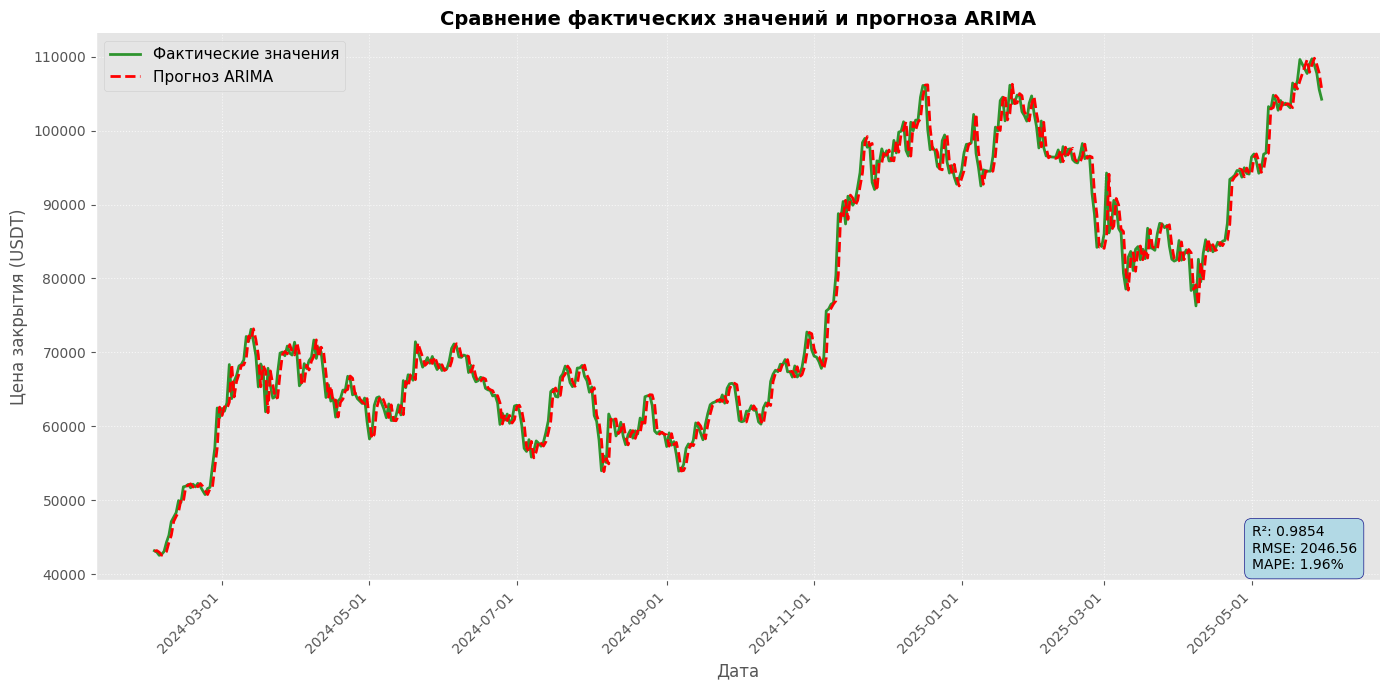

In [13]:
plt.figure(figsize=(14, 7))
test_dates = df.index[size:size + len(test)]

plt.plot(test_dates, test, label='Фактические значения', color='g', linewidth=2, alpha=0.8)
plt.plot(test_dates, predictions, label='Прогноз ARIMA', linestyle='--', color='r', linewidth=2)

plt.title('Сравнение фактических значений и прогноза ARIMA', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена закрытия (USDT)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')

metrics_text = (f'R²: {r2:.4f}\n'
                f'RMSE: {rmse:.2f}\n'
                f'MAPE: {mape:.2f}%')

plt.text(0.9, 0.1, metrics_text, transform=plt.gca().transAxes,
         bbox=dict(facecolor='lightblue', edgecolor='navy', boxstyle='round,pad=0.5', alpha=0.9),
         fontsize=10, verticalalignment='top')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
df = pd.read_csv('bybit_daily.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')  # Конвертация из миллисекунд
df = df.set_index('timestamp')

df = df[df['volume'] > 0]
df = df[(df['close'] > df['close'].quantile(0.001)) & 
        (df['close'] < df['close'].quantile(0.999))]

if len(df) < 100:
    raise ValueError("Недостаточно данных после очистки!")

model = ARIMA(df['close'], order=(2,1,1))
model_fit = model.fit()

# Прогноз на 10 дней
last_date = df.index[-1]
forecast = model_fit.forecast(steps=10)
forecast_dates = pd.date_range(
    start=last_date + pd.DateOffset(days=1),
    periods=10,
    freq='D'
)

print("\nПоследняя историческая дата:", last_date)
print("\nПрогноз:")
for date, value in zip(forecast_dates, forecast):
    print(f"{date.strftime('%Y-%m-%d')}: {value:.2f}")


Последняя историческая дата: 2025-05-30 00:00:00

Прогноз:
2025-05-31: 104353.59
2025-06-01: 104389.67
2025-06-02: 104428.18
2025-06-03: 104465.12
2025-06-04: 104500.77
2025-06-05: 104535.14
2025-06-06: 104568.30
2025-06-07: 104600.28
2025-06-08: 104631.12
2025-06-09: 104660.87



Результаты прогнозирования:
Последние 5 реальных значений: [108976.2 109707.5 108864.  107738.9 105550. ]
MSE: 543356318.570998


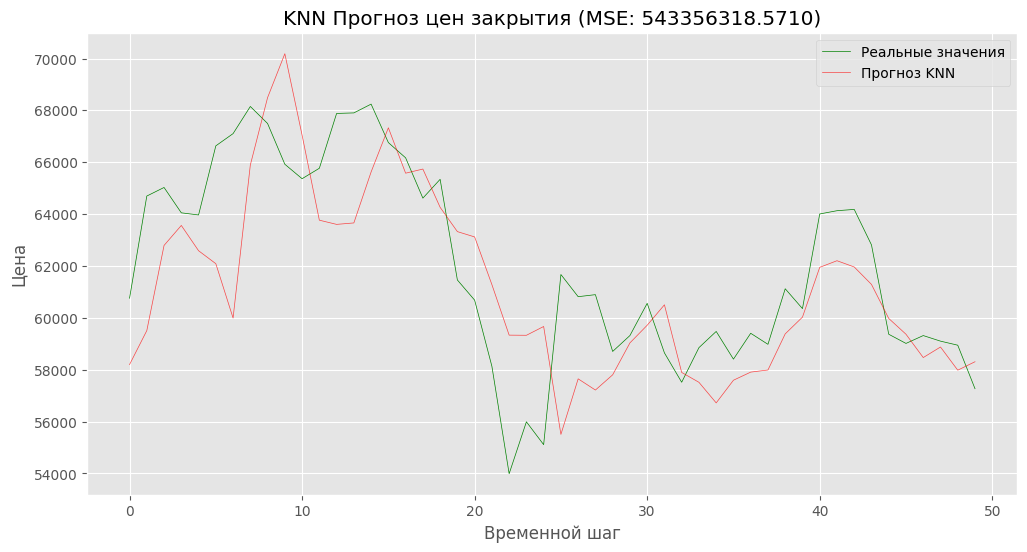

In [15]:
def knn_predict(csv_file, k=5, window_size=10, predict_next=1, test_size=0.2):
    try:
        df = pd.read_csv('bybit_daily.csv')
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.set_index('timestamp', inplace=True)
        closes = df['close'].values.astype(float)
        
        X, y = [], []
        for i in range(len(closes) - window_size - predict_next):
            X.append(closes[i:i+window_size])
            y.append(closes[i+window_size])

        X = np.array(X)
        y = np.array(y)
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # KNN
        predictions = []
        for test_sample in X_test:
            distances = np.linalg.norm(X_train - test_sample, axis=1)
            nearest_indices = np.argpartition(distances, k)[:k]
            prediction = np.mean(y_train[nearest_indices])
            predictions.append(prediction)
            
        mse = mean_squared_error(y_test, predictions)
        
        return np.array(predictions), y_test, mse
        
    except Exception as e:
        print(f"Ошибка: {str(e)}")
        return None, None, None

if __name__ == "__main__":
    csv_path = "bybit_daily.csv"
    predictions, true_values, mse = knn_predict(csv_file=csv_path, k=5, window_size=10, predict_next=1, test_size=0.2)

    if predictions is not None:
        print(f"\nРезультаты прогнозирования:")
        print(f"Последние 5 реальных значений: {true_values[-5:]}")
        print(f"MSE: {mse:.6f}")
        
        plt.figure(figsize=(12, 6))
        plt.plot(true_values[:50], label='Реальные значения', color='green')
        plt.plot(predictions[:50], label='Прогноз KNN', color='red', alpha=0.7)
        plt.title(f"KNN Прогноз цен закрытия (MSE: {mse:.4f})")
        plt.xlabel("Временной шаг")
        plt.ylabel("Цена")
        plt.legend()
        plt.show()

In [16]:
try:
    df = pd.read_csv('bybit_daily.csv')
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    print("Данные успешно загружены:")
    print(df.head())
    print(df.tail())
except Exception as e:
    print(f"Ошибка загрузки данных: {str(e)}")

Данные успешно загружены:
               open     high      low    close     volume      turnover
timestamp                                                              
2021-01-01  28921.5  29673.5  28654.0  29325.0  19234.412  5.640491e+08
2021-01-02  29325.0  33450.0  28967.5  32230.0  47478.703  1.530239e+09
2021-01-03  32230.0  34820.0  32016.5  32963.0  46033.177  1.517392e+09
2021-01-04  32963.0  33616.5  27923.0  32024.0  55935.783  1.791288e+09
2021-01-05  32024.0  34496.5  29905.5  34019.5  39382.593  1.339776e+09
                open      high       low     close      volume      turnover
timestamp                                                                   
2025-05-26  108976.2  110209.3  108640.7  109707.5   37597.284  4.121080e+09
2025-05-27  109382.3  110700.0  107421.7  108864.0  124854.197  1.364759e+10
2025-05-28  108864.0  109217.8  106718.0  107738.9   74593.391  8.057426e+09
2025-05-29  107738.9  108850.0  105250.0  105550.0  109918.170  1.178482e+10
2025-05-

In [17]:
window_size = 20  
predict_next = 1  
closes = df['close'].values.astype(float)

X, y = [], []
for i in range(len(closes) - window_size - predict_next):
    X.append(closes[i:i+window_size])
    y.append(closes[i+window_size:i+window_size+predict_next])

X = np.array(X)
y = np.array(y).squeeze()

print(f"\nСоздано {len(X)} примеров:")
print("Размер X:", X.shape)
print("Размер y:", y.shape)


Создано 1589 примеров:
Размер X: (1589, 20)
Размер y: (1589,)


In [18]:
test_size = 0.3 
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=test_size, 
    shuffle=False 
)

print(f"\nРазделение данных:")
print(f"Обучающая выборка: {len(X_train)} примеров")
print(f"Тестовая выборка: {len(X_test)} примеров")


Разделение данных:
Обучающая выборка: 1112 примеров
Тестовая выборка: 477 примеров


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nНормализация завершена:")
print("Пример тренировочных данных:", X_train_scaled[0])


Нормализация завершена:
Пример тренировочных данных: [-0.45116706 -0.21970799 -0.16174881 -0.23743117 -0.07841385  0.14151097
  0.3601135   0.45029422  0.40486549  0.2524155   0.02895729 -0.0753803
  0.19073151  0.33013281  0.13403747  0.07597056  0.06555388  0.12817065
  0.0662164   0.03236959]


In [20]:
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_sample in X_test:
        distances = np.linalg.norm(X_train - test_sample, axis=1)
        nearest_indices = np.argpartition(distances, k)[:k]
        prediction = np.mean(y_train[nearest_indices])
        predictions.append(prediction)
    return np.array(predictions)

In [21]:
k = 5 
predictions = knn_predict(X_train_scaled, y_train, X_test_scaled, k=k)
mse = mean_squared_error(y_test, predictions)
print("\nРезультаты прогнозирования:")
print(f"MSE: {mse:.6f}")
print(f"Последние 5 предсказаний: {predictions[-5:]}")
print(f"Соответствующие реальные значения: {y_test[-5:]}")


Результаты прогнозирования:
MSE: 528984018.513085
Последние 5 предсказаний: [61327.  61327.  61327.  61327.  59840.2]
Соответствующие реальные значения: [108976.2 109707.5 108864.  107738.9 105550. ]


In [22]:
maindf=pd.read_csv('./bybit_daily.csv')

print('Дней в датасете: ',maindf.shape[0])
print('Колонок (полей) в датасете: ',maindf.shape[1])
maindf.drop(columns=['volume','turnover'],inplace=True) if 'volume' in maindf.columns and 'turnover' in maindf.columns else None
maindf.tail()

Дней в датасете:  1610
Колонок (полей) в датасете:  7


,timestamp,open,high,low,close
1605,1748217600000,108976.2,110209.3,108640.7,109707.5
1606,1748304000000,109382.3,110700.0,107421.7,108864.0
1607,1748390400000,108864.0,109217.8,106718.0,107738.9
1608,1748476800000,107738.9,108850.0,105250.0,105550.0
1609,1748563200000,105550.0,106278.3,103666.0,104242.2


In [23]:
closedf = maindf.iloc[-400:].copy()  # последние 400 записей(дней)
close_stock = closedf.copy()
print("Total data for prediction: ", closedf.shape[0])
closedf.head()
closedf.tail()

Total data for prediction:  400


,timestamp,open,high,low,close
1605,1748217600000,108976.2,110209.3,108640.7,109707.5
1606,1748304000000,109382.3,110700.0,107421.7,108864.0
1607,1748390400000,108864.0,109217.8,106718.0,107738.9
1608,1748476800000,107738.9,108850.0,105250.0,105550.0
1609,1748563200000,105550.0,106278.3,103666.0,104242.2


In [24]:
try:
    maindf['timestamp'] = pd.to_datetime(maindf['timestamp'], unit='ms')
except OutOfBoundsDatetime:
    try:
        maindf['timestamp'] = pd.to_datetime(maindf['timestamp'], unit='s')
    except OutOfBoundsDatetime:
        maindf['timestamp'] = pd.to_datetime(maindf['timestamp'], errors='coerce')

maindf = maindf.dropna(subset=['timestamp'])
last_date = maindf['timestamp'].max()
one_year_ago = last_date - pd.DateOffset(years=1) 
last_year_df = maindf[maindf['timestamp'] >= one_year_ago]
closedf = maindf.iloc[-400:].copy() # Последние 400 строк
close_stock = closedf.copy()

print("Всего данных: ", len(maindf))
print("Данных для прогноза (closedf): ", closedf.shape[0])
print(f"Период closedf: {closedf['timestamp'].min().date()} – {closedf['timestamp'].max().date()}")

fig = px.line(
    closedf, 
    x='timestamp', 
    y='close', 
    labels={'timestamp': 'Дата', 'close': 'Цена закрытия'},
    title=f'Цена Bitcoin за последние {len(closedf)} дней'
)

fig.update_traces(line_color='orange', line_width=2, opacity=0.8)
fig.update_layout(
    plot_bgcolor='white', 
    font_size=15, 
    font_color='black',
    xaxis_title="Дата",
    yaxis_title="Цена закрытия"
)
fig.update_xaxes(
    showgrid=False, 
    tickformat="%Y-%m-%d", 
    tickangle=45,
    range=[closedf['timestamp'].min(), closedf['timestamp'].max()]
)
fig.update_yaxes(showgrid=False)
fig.show()

Всего данных:  1610
Данных для прогноза (closedf):  400
Период closedf: 2024-04-26 – 2025-05-30


In [25]:
if 'timestamp' in closedf.columns:
    closedf.drop(columns=['timestamp'], inplace=True)
print(closedf.shape)

prices = closedf['close'].values.flatten()  
print("Shape цен закрытия:", prices.shape)
prices_log = np.log1p(prices)  
print("Логарифмированные цены (первые 5):", prices_log[:5])

scaler_log = RobustScaler(with_centering=True, with_scaling=True)
closedf_scaled = scaler_log.fit_transform(prices_log.reshape(-1, 1))
print("После RobustScaler:", closedf_scaled.shape)
print("\nПервые 5 строк scaled data:")
print(closedf_scaled[:5])

(400, 4)
Shape цен закрытия: (400,)
Логарифмированные цены (первые 5): [11.0626774  11.05743836 11.05237779 11.06396134 11.01298868]
После RobustScaler: (400, 1)

Первые 5 строк scaled data:
[[-0.50199588]
 [-0.51465206]
 [-0.5268771 ]
 [-0.4988942 ]
 [-0.62203108]]


In [26]:
training_size = int(len(closedf_scaled) * 0.80)
test_size = len(closedf_scaled) - training_size
train_data, test_data = closedf_scaled[0:training_size, :], closedf_scaled[training_size:len(closedf_scaled), :]
print("train_data: ", train_data.shape)
print("test_data: ", test_data.shape)

train_data:  (320, 1)
test_data:  (80, 1)


In [27]:
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]   
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [28]:
time_step = 14  # Шаг
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test", y_test.shape)

X_train:  (305, 14)
y_train:  (305,)
X_test:  (65, 14)
y_test (65,)


In [29]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
print("X_train reshaped: ", X_train.shape)
print("X_test reshaped: ", X_test.shape)

X_train reshaped:  (305, 14, 1)
X_test reshaped:  (65, 14, 1)


In [30]:
model = Sequential([
    tf.keras.Input(shape=(None, 1)), 
    LSTM(32, activation="tanh", recurrent_dropout=0.1, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(16, activation="tanh", recurrent_dropout=0.1),
    Dropout(0.1),
    Dense(1)
])

In [31]:
physical_devices = tf.config.list_physical_devices('GPU') # GPU ускорение, если есть
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("✅ GPU найдено и активировано!")
else:
    print("⚠️ GPU не найдено, обучение на CPU.")

val_size = int(0.1 * len(X_test))
X_val, y_val = X_test[:val_size], y_test[:val_size]

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(128).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(128).prefetch(tf.data.AUTOTUNE)

# Двухслойная модель
model = Sequential([
    Bidirectional(LSTM(128, activation="tanh", recurrent_dropout=0.1, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.2),
    Bidirectional(LSTM(64, activation="tanh", recurrent_dropout=0.1)),
    Dropout(0.1),
    Dense(1),
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

model.save('btc_daily_lstm_model.keras')
joblib.dump(scaler_log, 'scaler_log_daily.save')
print("✅ Модель и скалер сохранены!")

⚠️ GPU не найдено, обучение на CPU.
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - loss: 0.4622 - mae: 0.5701 - val_loss: 0.2203 - val_mae: 0.4036
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1102 - mae: 0.2775 - val_loss: 0.2401 - val_mae: 0.4186
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0530 - mae: 0.1838 - val_loss: 0.2319 - val_mae: 0.4101
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0535 - mae: 0.1869 - val_loss: 0.2361 - val_mae: 0.4140
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0426 - mae: 0.1594 - val_loss: 0.2341 - val_mae: 0.4130
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0418 - mae: 0.1564 - val_loss: 0.2437 - val_mae: 0.4215
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0430 - mae: 0.1654 - val_loss: 0.2434 - val_mae: 0.4181
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0394 - mae: 0.1591 - val_loss: 0.2362 - val_mae: 0.4109
Epoch 9/100
10/10 

In [32]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)
train_predict = scaler_log.inverse_transform(train_predict)
test_predict = scaler_log.inverse_transform(test_predict)
original_ytrain = scaler_log.inverse_transform(y_train.reshape(-1,1)) 
original_ytest = scaler_log.inverse_transform(y_test.reshape(-1,1)) 
train_predict = np.expm1(train_predict)
test_predict = np.expm1(test_predict)
original_ytrain = np.expm1(original_ytrain)
original_ytest = np.expm1(original_ytest)
print("Train data RMSE: ", math.sqrt(mean_squared_error(original_ytrain,train_predict)))
print("Train data MSE: ", mean_squared_error(original_ytrain,train_predict))
print("Train data MAE: ", mean_absolute_error(original_ytrain,train_predict))
print("-------------------------------------------------------------------------------------")
print("Test data RMSE: ", math.sqrt(mean_squared_error(original_ytest,test_predict)))
print("Test data MSE: ", mean_squared_error(original_ytest,test_predict))
print("Test data MAE: ", mean_absolute_error(original_ytest,test_predict))

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Train data RMSE:  2190.287578154958
Train data MSE:  4797359.6750199115
Train data MAE:  1652.3437551229508
-------------------------------------------------------------------------------------
Test data RMSE:  2783.094753680471
Test data MSE:  7745616.407963761
Test data MAE:  2052.1458653846175


In [ ]:
look_back = time_step  
trainPredictPlot = np.empty_like(closedf_scaled)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
print("Train predicted data: ", trainPredictPlot.shape)
testPredictPlot = np.empty_like(closedf_scaled)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(closedf_scaled)-1, :] = test_predict
print("Test predicted data: ", testPredictPlot.shape)

plotdf = pd.DataFrame({
                       'original_close': closedf['close'].values,  # настоящие цены
                      'train_predicted_close': trainPredictPlot.reshape(1,-1)[0].tolist(),
                      'test_predicted_close': testPredictPlot.reshape(1,-1)[0].tolist()})

plotdf['date'] = np.arange(len(plotdf))
names = cycle(['Настоящая цена ','Предсказанный Train','Предсказанный Test'])

fig = px.line(plotdf,x=plotdf['date'], y=[plotdf['original_close'],plotdf['train_predicted_close'],
                                          plotdf['test_predicted_close']],
              labels={'value':'Цена BTC/USDT','date': 'Days'})
fig.update_layout(title_text='Предсказания по BTC/USDT с помощью LSTM на временном интервале',
                  plot_bgcolor='white', font_size=15, font_color='black', legend_title_text='Тип')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False, type='log')  # Логарифмическая шкала цен (опционально)
fig.show()

Train predicted data:  (400, 1)
Test predicted data:  (400, 1)


In [34]:
x_input = test_data[-time_step:].reshape(1, -1)  
temp_input = list(x_input)
temp_input = temp_input[0].tolist()

lst_output = []
n_steps = time_step 
i = 0
pred_days = 10  

while(i < pred_days):
    
    if(len(temp_input) > time_step):
        x_input = np.array(temp_input[1:])
        x_input = x_input.reshape(1, -1)
        x_input = x_input.reshape((1, n_steps, 1))
        
        yhat = model.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())
        temp_input = temp_input[1:]  
        lst_output.extend(yhat.tolist())
        i = i + 1
        
    else:
        x_input = x_input.reshape((1, n_steps, 1))
        yhat = model.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())
        lst_output.extend(yhat.tolist())
        i = i + 1
               
print("Output of predicted next days: ", len(lst_output))

Output of predicted next days:  10


In [35]:
import datetime

last_days = np.arange(1, 11) # Последние 10 дней 
day_pred = np.arange(11, 11 + pred_days) # Предсказанные 10 дней

print(last_days)  
print(day_pred)  
last_10_dates = close_stock['timestamp'].iloc[-10:].values  # datetime64[ns]
last_10_dates = [datetime.datetime.fromtimestamp(date / 1e9).strftime('%Y-%m-%d') 
                 for date in last_10_dates.astype('int64')]

last_date = close_stock['timestamp'].iloc[-1].to_pydatetime()
future_dates = [(last_date + datetime.timedelta(days=i+1)).strftime('%Y-%m-%d') for i in range(pred_days)]
all_dates = last_10_dates + future_dates

temp_mat = np.empty((len(last_days) + pred_days, 1))
temp_mat[:] = np.nan
temp_mat = temp_mat.reshape(1, -1).tolist()[0]

last_original_days_value = temp_mat.copy()
next_predicted_days_value = temp_mat.copy()

actual_last_10_scaled = y_test[-10:]  
actual_last_10 = scaler_log.inverse_transform(actual_last_10_scaled.reshape(-1, 1)).flatten()
actual_last_10 = np.expm1(actual_last_10)  

last_original_days_value[:len(last_days)] = actual_last_10.tolist()

predicted_scaled = np.array(lst_output).reshape(-1, 1)
predicted_prices = scaler_log.inverse_transform(predicted_scaled).flatten()
predicted_prices = np.expm1(predicted_prices)  

next_predicted_days_value[-len(predicted_prices):] = predicted_prices.tolist()

new_pred_plot = pd.DataFrame({
    'Date': all_dates,
    'last_original_days_value': last_original_days_value,
    'next_predicted_days_value': next_predicted_days_value
})

names = cycle(['Цена за последние 10 дней', 'Предсказанные 10 дней'])

fig = px.line(new_pred_plot, x='Date', y=['last_original_days_value', 'next_predicted_days_value'],
              labels={'value': 'Цена BTC/USDT', 'Date': 'Дата'})
fig.update_layout(title_text='Цена за последние 10 дней + Предсказанные 10 дней',
                  plot_bgcolor='white', font_size=15, font_color='black', legend_title_text='Тип',
                  xaxis=dict(tickangle=-45)) 

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False, type='category')
fig.update_yaxes(showgrid=False, type='log')
fig.show()

[ 1  2  3  4  5  6  7  8  9 10]
[11 12 13 14 15 16 17 18 19 20]


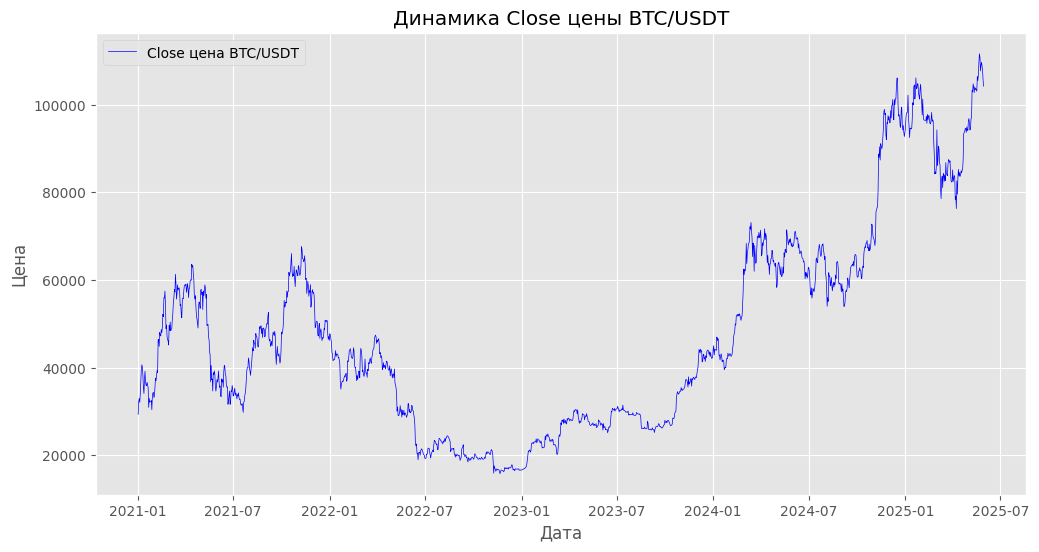

In [36]:
df = pd.read_csv('bybit_daily.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df['close'], label='Close цена BTC/USDT', color='blue')
plt.title('Динамика Close цены BTC/USDT')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
X = df.drop('close', axis=1)
y = df['close']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=False)

In [38]:
df = pd.read_csv('bybit_daily.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

df['lag_7'] = df['close'].shift(7)
df['rolling_mean_30'] = df['close'].rolling(30).mean().fillna(0)
df = df[(df['close'] > df['close'].quantile(0.05)) & (df['close'] < df['close'].quantile(0.95))].copy()
df = df.dropna()

y = np.log(df['close'])
X = df.drop('close', axis=1)

last_date = X.index.max()
train_end_date = last_date - pd.DateOffset(days=test_size)

X_train = X[X.index <= train_end_date]
y_train = y[X_train.index]
X_test = X[X.index > train_end_date]
y_test = y[X_test.index]

print("\nВременные диапазоны данных:")
print(f"- Обучение (Train): от {X_train.index.min()} до {X_train.index.max()}")
print(f"- Тестирование (Test): от {X_test.index.min()} до {X_test.index.max()}")
print(f"- Всего данных для обучения: {len(X_train)} строк")
print(f"- Всего данных для теста: {len(X_test)} строк")

model = lgb.LGBMRegressor(boosting_type='gbdt')
param_grid = {
    'n_estimators': [2500],
    'num_leaves': [30],
    'learning_rate': [0.02],
    'max_depth': [8],
    'reg_alpha': [0.1],
    'reg_lambda': [0.1]
}

tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


Временные диапазоны данных:
- Обучение (Train): от 2021-01-08 00:00:00 до 2025-02-13 00:00:00
- Тестирование (Test): от 2025-02-16 00:00:00 до 2025-05-06 00:00:00
- Всего данных для обучения: 1362 строк
- Всего данных для теста: 79 строк


In [39]:
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, np.exp(y_pred)))
importances = pd.Series(best_model.feature_importances_, index=X.columns)
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"RMSE на тестовых данных: {rmse:.2f}")
print("\nВажность признаков:\n", importances.sort_values(ascending=False))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 1362, number of used features: 7
[LightGBM] [Info] Start training from score 10.604292
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


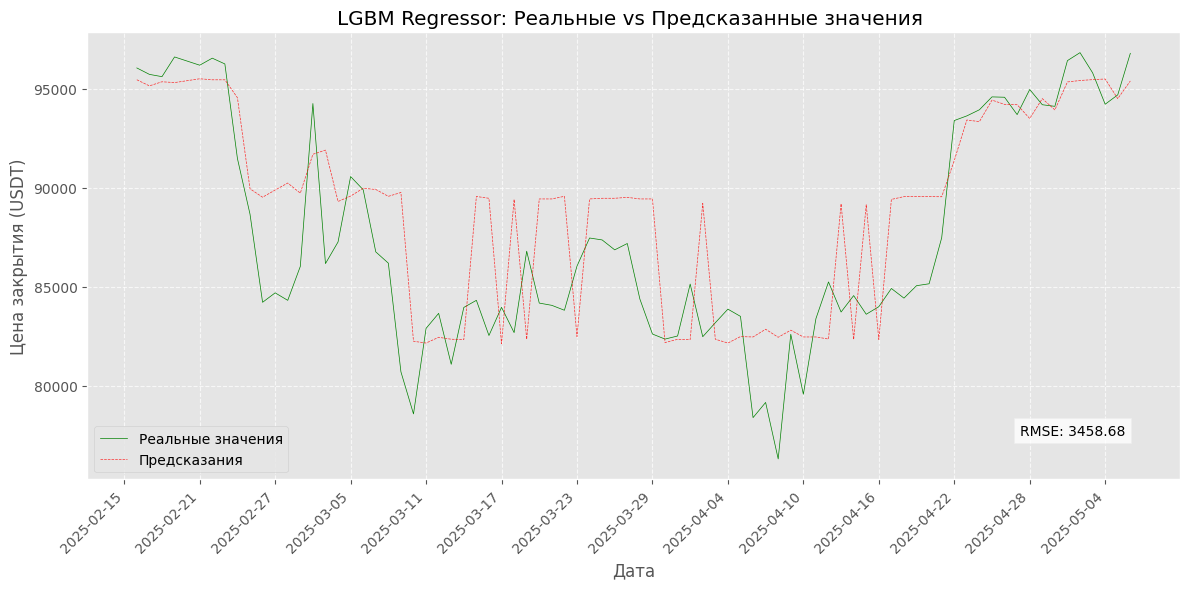

In [40]:
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))

plt.figure(figsize=(12, 6))
plt.plot(y_test_exp.index, y_test_exp.values, label='Реальные значения', color='green')
plt.plot(y_test_exp.index, y_pred_exp, label='Предсказания', color='red', linestyle='--', alpha=0.8)

plt.title(f'LGBM Regressor: Реальные vs Предсказанные значения ')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия (USDT)')
plt.legend()

plt.text(
    x=0.95, 
    y=0.1, 
    s=f'RMSE: {rmse:.2f}', 
    transform=plt.gca().transAxes,
    ha='right',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))
plt.gcf().autofmt_xdate(rotation=45)

plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
best_model = lgb.LGBMRegressor()
best_model.fit(X_train, y_train)

CONFIDENCE_INTERVAL = 0.03  # ±3% доверительный интервал
REFIT_WINDOW = 7 # Переобучаем каждые 7 дней
FORECAST_HORIZON = 30  # Прогноз на 30 дней

future_dates = pd.date_range(start=y_test.index[-1] + pd.DateOffset(days=1), periods=FORECAST_HORIZON)
future_prices = []
upper_band = []
lower_band = []

last_data = X_test.iloc[-1].copy()
last_close_exp = np.exp(y_test.iloc[-1])

for step in range(FORECAST_HORIZON):
    last_data_df = pd.DataFrame([last_data], columns=X.columns)
    next_price_log = best_model.predict(last_data_df)[0]
    next_price = np.exp(next_price_log)
    
    future_prices.append(next_price)
    upper_band.append(next_price * (1 + CONFIDENCE_INTERVAL))
    lower_band.append(next_price * (1 - CONFIDENCE_INTERVAL))
    
    next_row = last_data.copy()
    if 'lag_7' in next_row.index:
        next_row['lag_7'] = last_close_exp
    if 'rolling_mean_30' in next_row.index:
        prev_mean = last_data['rolling_mean_30']
        next_row['rolling_mean_30'] = (prev_mean * 29 + next_price) / 30 # скользящее среднее
    
    last_data = next_row
    last_close_exp = next_price

    if (step + 1) % REFIT_WINDOW == 0 and step < FORECAST_HORIZON - 1:
        new_train_end = future_dates[step]
        new_X_train = pd.concat([X_train, X_test[X_test.index <= new_train_end]])
        new_y_train = pd.concat([y_train, y_test[X_test.index <= new_train_end]])
        
        best_model.fit(new_X_train, new_y_train)
        print(f"🔄 Модель переобучена на шаге {step+1} (дата: {future_dates[step]})")

future_df = pd.DataFrame({
    'Дата': future_dates,
    'Прогноз Close': future_prices,
    'Верхний 3% интервал': upper_band,
    'Нижний 3% интервал': lower_band
}).set_index('Дата')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=future_df.index,
    y=future_df['Прогноз Close'].values,
    mode='lines+markers',
    name='Прогноз Close цены BTC',
    line=dict(color='red', width=2),
    marker=dict(size=6),
    hovertemplate='<b>Дата:</b> %{x|%Y-%m-%d}<br><b>Прогноз Close:</b> %{y:.2f} USDT<extra></extra>'
))
fig.add_trace(go.Scatter(
    x=future_df.index.tolist() + future_df.index.tolist()[::-1],
    y=future_df['Верхний 3% интервал'].tolist() + future_df['Нижний 3% интервал'].tolist()[::-1],
    fill='toself',
    fillcolor='rgba(0,100,80,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    name='±3% Доверительный интервал'
))
fig.add_trace(go.Scatter(
    x=future_df.index,
    y=future_df['Верхний 3% интервал'],
    mode='lines',
    line=dict(color='green', width=1, dash='dash'),
    name='Верхняя граница (+3%)',
    hovertemplate='<b>Дата:</b> %{x|%Y-%m-%d}<br><b>Верхний интервал:</b> %{y:.2f} USDT<extra></extra>'
))
fig.add_trace(go.Scatter(
    x=future_df.index,
    y=future_df['Нижний 3% интервал'],
    mode='lines',
    line=dict(color='green', width=1, dash='dash'),
    name='Нижняя граница (-3%)',
    hovertemplate='<b>Дата:</b> %{x|%Y-%m-%d}<br><b>Нижний интервал:</b> %{y:.2f} USDT<extra></extra>'
))

fig.update_layout(
    title=f' Прогноз Close цены BTC на {FORECAST_HORIZON} дней вперёд (с {future_df.index.min().strftime("%Y-%m-%d")})',
    xaxis_title='Дата',
    yaxis_title='Предсказанная Close цена (USDT)',
    template='plotly_white',
    width=1200,
    height=600,
    hovermode='x unified',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)
fig.update_xaxes(tickangle=45)
fig.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 1362, number of used features: 7
[LightGBM] [Info] Start training from score 10.604292
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 1441, number of used features: 7
[LightGBM] [Info] Start training from score 10.646664
🔄 Модель переобучена на шаге 7 (дата: 2025-05-13 00:00:00)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785

In [ ]:
#Blending Ensemble

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('bybit_daily.csv')
df.set_index('timestamp', inplace=True)

df['lag_1'] = df['close'].shift(1)
df['7_day_ma'] = df['close'].rolling(window=7).mean()
df['7_day_std'] = df['close'].rolling(window=7).std()
df['upper_band'] = df['7_day_ma'] + (df['7_day_std'] * 2)
df['lower_band'] = df['7_day_ma'] - (df['7_day_std'] * 2)
df['daily_return'] = df['close'].pct_change()

df.dropna(inplace=True)
df['target'] = df['close'].shift(-1)
df.dropna(inplace=True)
X = df.drop(['target', 'close'], axis=1)
y = df['target']

split_idx = int(0.7 * len(df))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

dates = df.index
train_dates, test_dates = dates[:split_idx], dates[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN
class KNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, k=5, window_size=10):
        self.k = k
        self.window_size = window_size
        
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def predict(self, X):
        X = np.array(X)
        predictions = []
        for test_sample in X:
            distances = np.linalg.norm(self.X_train - test_sample, axis=1)
            k_actual = min(self.k, len(distances))
            nearest_indices = np.argpartition(distances, k_actual)[:k_actual]
            prediction = np.mean(self.y_train[nearest_indices])
            predictions.append(prediction)
        return np.array(predictions)

# LSTM
class LSTMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=30, batch_size=32, sequence_length=10):
        self.epochs = epochs
        self.batch_size = batch_size
        self.sequence_length = sequence_length
        self.model = None
        self.scaler_y = StandardScaler()
        self.mean_prediction = 0
        
    def _create_sequences(self, data, target):
        X, y = [], []
        for i in range(len(data) - self.sequence_length):
            X.append(data[i:(i + self.sequence_length)])
            y.append(target[i + self.sequence_length])
        return np.array(X), np.array(y)
    
    def fit(self, X, y):
        try:
            X = np.array(X)
            y = np.array(y)
            self.mean_prediction = np.mean(y)
            
            y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
            X_seq, y_seq = self._create_sequences(X, y_scaled)
            
            if len(X_seq) < 10:  
                self.model = None
                return self
                
            X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], X_seq.shape[2]))
            
            self.model = Sequential([
                LSTM(128, activation="tanh", recurrent_dropout=0.1, return_sequences=True, input_shape=(X_seq.shape[1], X_seq.shape[2])),
                Dropout(0.2),
                BatchNormalization(),
                LSTM(64, activation="tanh", recurrent_dropout=0.1),
                Dropout(0.1),
                Dense(1)
            ])
            
            self.model.compile(optimizer='adam', loss='mse')
            
            early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
            
            self.model.fit(X_seq, y_seq, 
                           epochs=self.epochs,
                           batch_size=self.batch_size,
                           verbose=0, 
                           callbacks=[early_stopping])
        except Exception as e:
            print(f"LSTM training error: {e}")
            self.model = None
        return self
    
    def predict(self, X):
        try:
            X = np.array(X)
            if self.model is None:
                return np.full(len(X), self.mean_prediction)
                
            predictions = []
            for i in range(len(X)):
                try:
                    if i >= self.sequence_length:
                        seq = X[i-self.sequence_length:i].reshape(1, self.sequence_length, X.shape[1])
                    else:
                        seq = np.tile(X[i], (1, self.sequence_length, 1))
                    
                    pred_scaled = self.model.predict(seq, verbose=0)[0][0]
                    pred = self.scaler_y.inverse_transform([[pred_scaled]])[0][0]
                    predictions.append(pred)
                except:
                    predictions.append(self.mean_prediction)
            return np.array(predictions)
        except:
            return np.full(len(X), self.mean_prediction)

# ARIMA
class ARIMARegressor(BaseEstimator, RegressorMixin):
    def __init__(self, order=(2,1,1)):
        self.order = order
        self.model_fit = None
        self.mean_prediction = 0
        
    def fit(self, X, y):
        try:
            y = np.array(y)
            self.mean_prediction = np.mean(y)
            model = ARIMA(y, order=self.order)
            self.model_fit = model.fit()
            self.last_values = y[-50:]  
        except Exception as e:
            print(f"ARIMA fitting error: {e}")
            self.model_fit = None
            self.last_values = np.array([self.mean_prediction])
        return self
    
    def predict(self, X):
        if self.model_fit is None:
            return np.full(len(X), self.mean_prediction)
            
        try:
            forecast = self.model_fit.forecast(steps=len(X))
            return np.array(forecast)
        except Exception as e:
            print(f"ARIMA prediction error: {e}")
            return np.full(len(X), self.mean_prediction)

X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, shuffle=False)

knn_model = KNNRegressor(k=5)
lgb_model = lgb.LGBMRegressor(
    boosting_type='gbdt',
    n_estimators=2500,
    num_leaves=30,
    learning_rate=0.02,
    max_depth=8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)
lstm_model = LSTMRegressor(epochs=30, batch_size=16, sequence_length=10)
lr_model = Ridge(alpha=1.0)
arima_model = ARIMARegressor(order=(5,1,0))

print("Обучение базовых моделей...")
knn_model.fit(X_tr, y_tr)
lgb_model.fit(X_tr, y_tr)
lstm_model.fit(X_tr, y_tr)
lr_model.fit(X_tr, y_tr)
arima_model.fit(X_train.iloc[:len(X_tr)], y_tr)

print("Получение предсказаний на валидации...")
knn_val_pred = knn_model.predict(X_val)
lgb_val_pred = lgb_model.predict(X_val)
lstm_val_pred = lstm_model.predict(X_val)
lr_val_pred = lr_model.predict(X_val)
arima_val_pred = arima_model.predict(X_val)

X_val_blend = np.column_stack([knn_val_pred, lgb_val_pred, lstm_val_pred, lr_val_pred, arima_val_pred])

print("Обучение мета-модели...")
blender = Ridge(alpha=1.0)
blender.fit(X_val_blend, y_val)

print("Получение предсказаний на тесте...")
knn_test_pred = knn_model.predict(X_test_scaled)
lgb_test_pred = lgb_model.predict(X_test_scaled)
lstm_test_pred = lstm_model.predict(X_test_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
arima_test_pred = arima_model.predict(X_test)

X_test_blend = np.column_stack([knn_test_pred, lgb_test_pred, lstm_test_pred, lr_test_pred, arima_test_pred])

print("Финальное предсказание...")
blend_pred = blender.predict(X_test_blend)

blend_rmse = np.sqrt(mean_squared_error(y_test, blend_pred))
blend_mae = mean_absolute_error(y_test, blend_pred)
blend_r2 = r2_score(y_test, blend_pred)

print(f"\nРезультаты Blending Ensemble:")
print(f"RMSE: {blend_rmse:.4f}")
print(f"MAE: {blend_mae:.4f}")
print(f"R²: {blend_r2:.4f}")

print(f"\nИндивидуальные RMSE:")
print(f"KNN RMSE: {np.sqrt(mean_squared_error(y_test, knn_test_pred)):.4f}")
print(f"LightGBM RMSE: {np.sqrt(mean_squared_error(y_test, lgb_test_pred)):.4f}")
print(f"LSTM RMSE: {np.sqrt(mean_squared_error(y_test, lstm_test_pred)):.4f}")
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, lr_test_pred)):.4f}")
print(f"ARIMA RMSE: {np.sqrt(mean_squared_error(y_test, arima_test_pred)):.4f}")

train_blend_pred = blender.predict(np.column_stack([
    knn_model.predict(X_train_scaled),
    lgb_model.predict(X_train_scaled),
    lstm_model.predict(X_train_scaled),
    lr_model.predict(X_train_scaled),
    arima_model.predict(X_train)
]))
train_blend_rmse = np.sqrt(mean_squared_error(y_train, train_blend_pred))

print(f"\nПроверка на переобучение:")
print(f"Train RMSE: {train_blend_rmse:.4f}")
print(f"Test RMSE: {blend_rmse:.4f}")
print(f"Разница: {abs(blend_rmse - train_blend_rmse):.4f}")

if abs(blend_rmse - train_blend_rmse) / train_blend_rmse > 0.2:
    print("⚠️ Возможно переобучение!")
else:
    print("✅ Переобучение под контролем.")

Обучение базовых моделей...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 897, number of used features: 11
[LightGBM] [Info] Start training from score 35389.841462
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

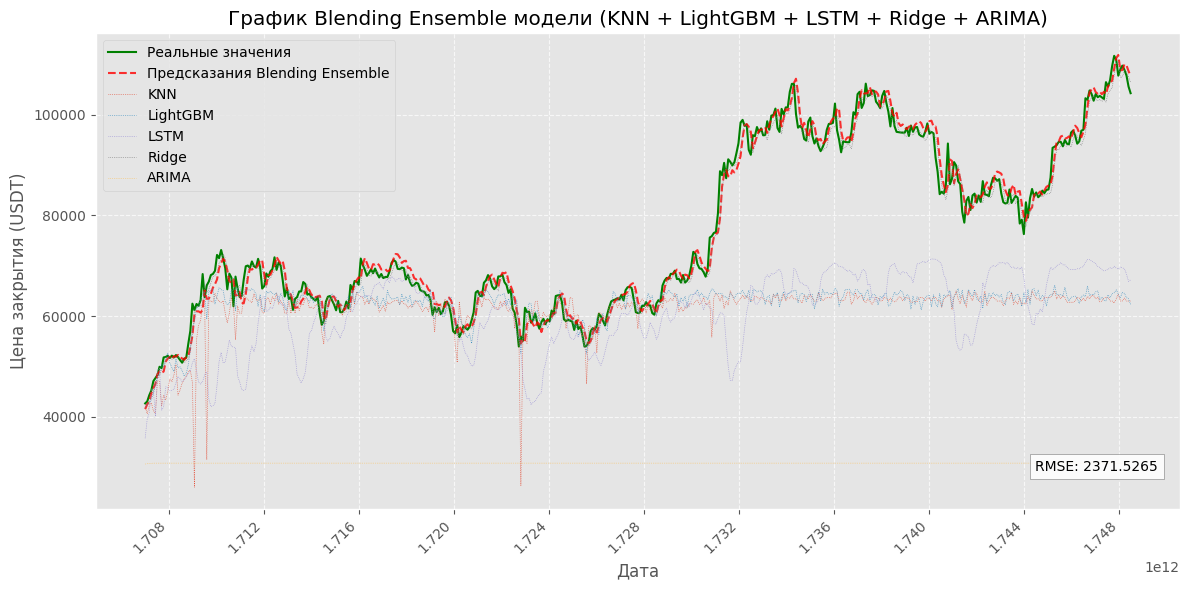

In [47]:
y_test_exp = y_test
y_pred_exp = blend_pred

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))

plt.figure(figsize=(12, 6))
plt.plot(y_test_exp.index, y_test_exp.values, label='Реальные значения', color='green', linewidth=1.5)
plt.plot(y_test_exp.index, y_pred_exp, label='Предсказания Blending Ensemble', color='red', linestyle='--', alpha=0.8, linewidth=1.5)

plt.title(f'График Blending Ensemble модели (KNN + LightGBM + LSTM + Ridge + ARIMA)')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия (USDT)')
plt.legend(loc='upper left', fontsize=10)

plt.text(
    x=0.98, 
    y=0.08, 
    s=f'RMSE: {rmse:.4f}', 
    transform=plt.gca().transAxes,
    ha='right',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.gcf().autofmt_xdate(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

plt.plot(y_test_exp.index, knn_test_pred, label='KNN', linestyle=':')
plt.plot(y_test_exp.index, lgb_test_pred, label='LightGBM', linestyle=':')
plt.plot(y_test_exp.index, lstm_test_pred, label='LSTM', linestyle=':')
plt.plot(y_test_exp.index, lr_test_pred, label='Ridge', linestyle=':')
plt.plot(y_test_exp.index, arima_test_pred, label='ARIMA', linestyle=':')
plt.legend()

plt.show()

In [ ]:
last_10_days_dates = test_dates[-10:]
last_10_days_values = y_test.values[-10:]
last_timestamp = test_dates[-1]
last_date = pd.to_datetime(last_timestamp, unit='ms')  # миллисекунды!

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=10,
    freq='D'
)

initial_future_features = []
last_row = X_test.iloc[-1]

for i in range(10):
    new_row = last_row.copy()
    if i == 0:
        new_row['lag_1'] = y_test.values[-1]
    else:
        new_row['lag_1'] = initial_future_features[i-1]['lag_1']
    new_row['7_day_ma'] = X_test['7_day_ma'].values[-1]
    new_row['7_day_std'] = X_test['7_day_std'].values[-1]
    new_row['upper_band'] = X_test['upper_band'].values[-1]
    new_row['lower_band'] = X_test['lower_band'].values[-1]
    new_row['daily_return'] = 0
    initial_future_features.append(new_row)

initial_future_features = pd.DataFrame(initial_future_features)
initial_future_features_scaled = scaler.transform(initial_future_features)

knn_future_pred = knn_model.predict(initial_future_features_scaled)
lgb_future_pred = lgb_model.predict(initial_future_features_scaled)
lstm_future_pred = lstm_model.predict(initial_future_features_scaled)
lr_future_pred = lr_model.predict(initial_future_features_scaled)
arima_future_pred = arima_model.predict(initial_future_features)

X_future_blend = np.column_stack([
    knn_future_pred,
    lgb_future_pred,
    lstm_future_pred,
    lr_future_pred,
    arima_future_pred
])
future_blend_pred = blender.predict(X_future_blend)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=pd.to_datetime(last_10_days_dates, unit='ms'),
        y=last_10_days_values,
        mode='lines+markers',
        name='Последние 10 дней (реальные)',
        line=dict(color='green', width=2),
        marker=dict(size=6),
        hovertemplate='Дата: %{x|%Y-%m-%d}<br>Цена: %{y:.2f} USDT<extra></extra>'
    )
)

fig.add_trace(
    go.Scatter(
        x=future_dates,
        y=future_blend_pred,
        mode='lines+markers',
        name='Прогноз Blending Ensemble (10 дней вперёд)',
        line=dict(color='red', width=2, dash='dash'),
        marker=dict(size=6, symbol='circle'),
        hovertemplate='Дата: %{x|%Y-%m-%d}<br>Прогноз: %{y:.2f} USDT<extra></extra>'
    )
)

fig.update_layout(
    title='Прогноз блендинг ансамбля BTC/USDT на 10 дней вперёд',
    xaxis_title='Дата',
    yaxis_title='Цена закрытия (USDT)',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        font=dict(size=10)
    ),
    hoverlabel=dict(
        bgcolor="white",
        font_size=14,
        font_family="Rockwell"
    ),
    xaxis=dict(
        tickformat="%Y-%m-%d",
        tickangle=45
    ),
    margin=dict(l=50, r=20, t=70, b=50),
    width=1000,
    height=600
)

fig.show()